In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from PredictiveDecorrBSS import PredictiveDecorrBSS

# Generate Sources and Mix Them (5 by 3 case)

In [2]:
# def generate_nonnegative_l1_sources(n_sources, n_samples, radius=1.0):
#     """
#     Uniformly samples vectors from the intersection of the L1 ball 
#     and the non-negative quadrant.
#     """
#     # 1. Sample (n_sources + 1) exponential variables
#     # This is a standard way to get points on a simplex
#     # We add 1 to n_sources to sample from the *ball* (the volume) 
#     # rather than just the *sphere* (the surface).
#     x = np.random.exponential(scale=1.0, size=(n_sources + 1, n_samples))
    
#     # 2. Normalize by the sum
#     # Now, each column sums to 1 (unit simplex)
#     s_total = np.sum(x, axis=0)
#     x_norm = x / s_total
    
#     # 3. Discard the last dummy dimension
#     # The remaining n_sources dimensions are uniformly distributed 
#     # in the L1-ball (sum <= 1)
#     S = x_norm[:n_sources, :] * radius
    
#     return S

# def generate_vertex_sources_nnl1(n_sources, n_samples, include_zero=True):
#     """
#     Generates sources that are either one-hot or all-zero.
#     Each column is a vertex of the non-negative L1 ball.
#     """
#     S = np.zeros((n_sources, n_samples))
    
#     # Possible indices: 0 to n_sources-1 (the basis vectors) 
#     # and n_sources (representing the zero vector)
#     num_options = n_sources + 1 if include_zero else n_sources
    
#     # Randomly choose which source is active at each time step
#     active_indices = np.random.randint(0, num_options, size=n_samples)
    
#     for t in range(n_samples):
#         idx = active_indices[t]
#         if idx < n_sources: # If it's not the 'zero' option
#             S[idx, t] = 1.0
            
#     return S
# generate_nonnegative_l1_sources(NumberofSources, N)

In [3]:
# np.random.seed(400)
seed = np.random.randint(5000000)
# seed = 201
np.random.seed(seed)
print("seed is ", seed)
N = 100000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -2, max_val = 2)
S = ProjectRowstoL1NormBall(S.T).T 
S = S * (S >= 0)

# S = generate_vertex_sources_nnl1(NumberofSources, N)
# S = ProjectRowstoL1NormBall(S.T).T 
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  4352208
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.999999665951044


(array([0.04303369, 0.04318363, 0.04282191, 0.04300798, 0.04296375]),
 array([0.36087819, 0.13982302, 0.1921529 , 0.15395896, 0.1925907 ,
        0.2447067 , 0.16142741, 0.12593799, 0.14957535, 0.38976678]))

In [4]:
display_matrix(S @ S.T / S.shape[1] - np.outer(S.mean(1), S.mean(1)))

<IPython.core.display.Math object>

In [5]:
np.sum(S, axis = 0).max()

np.float64(1.000000000000001)

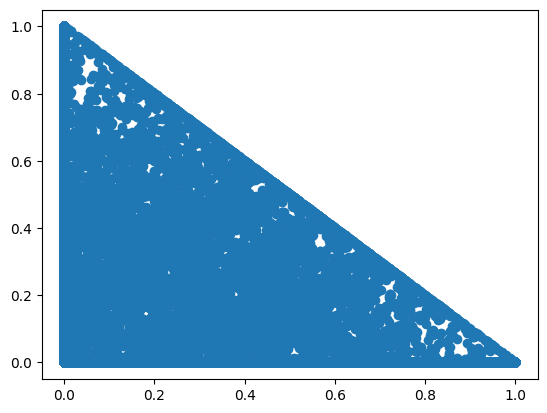

In [6]:
plt.scatter(S[0, :], S[1, :])

# Hyperparameters

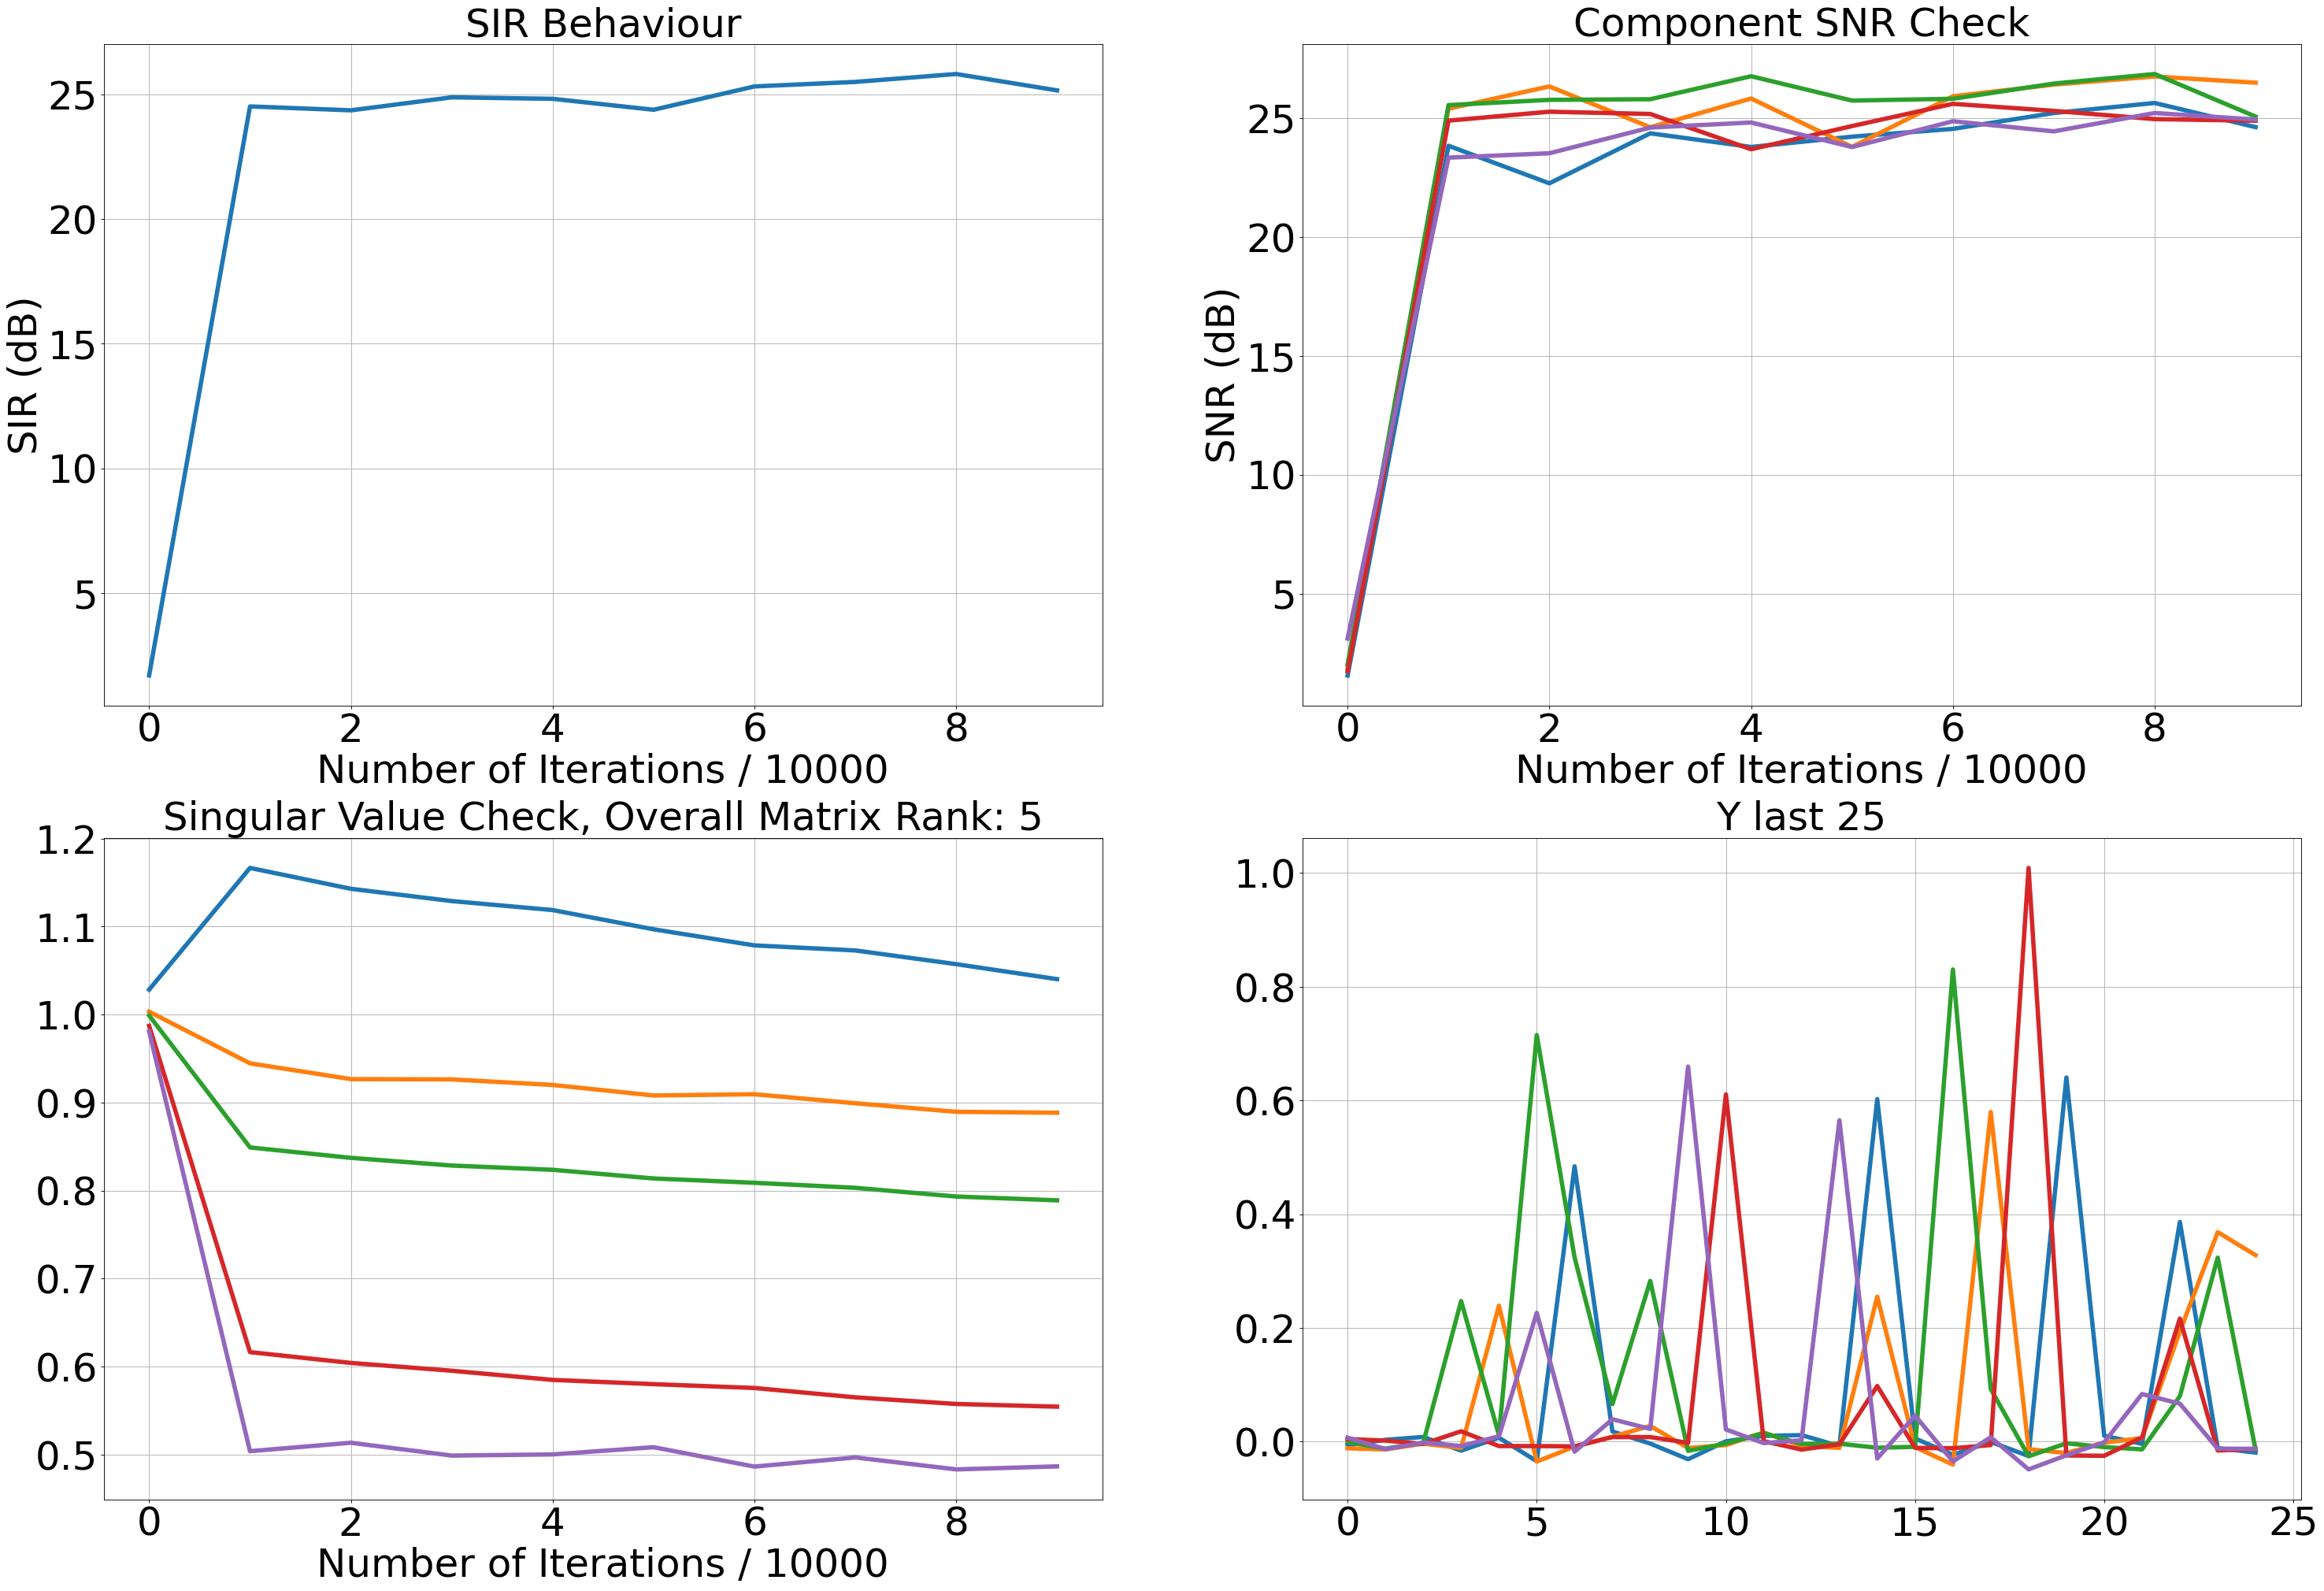

100%|██████████| 100000/100000 [00:26<00:00, 3745.53it/s]


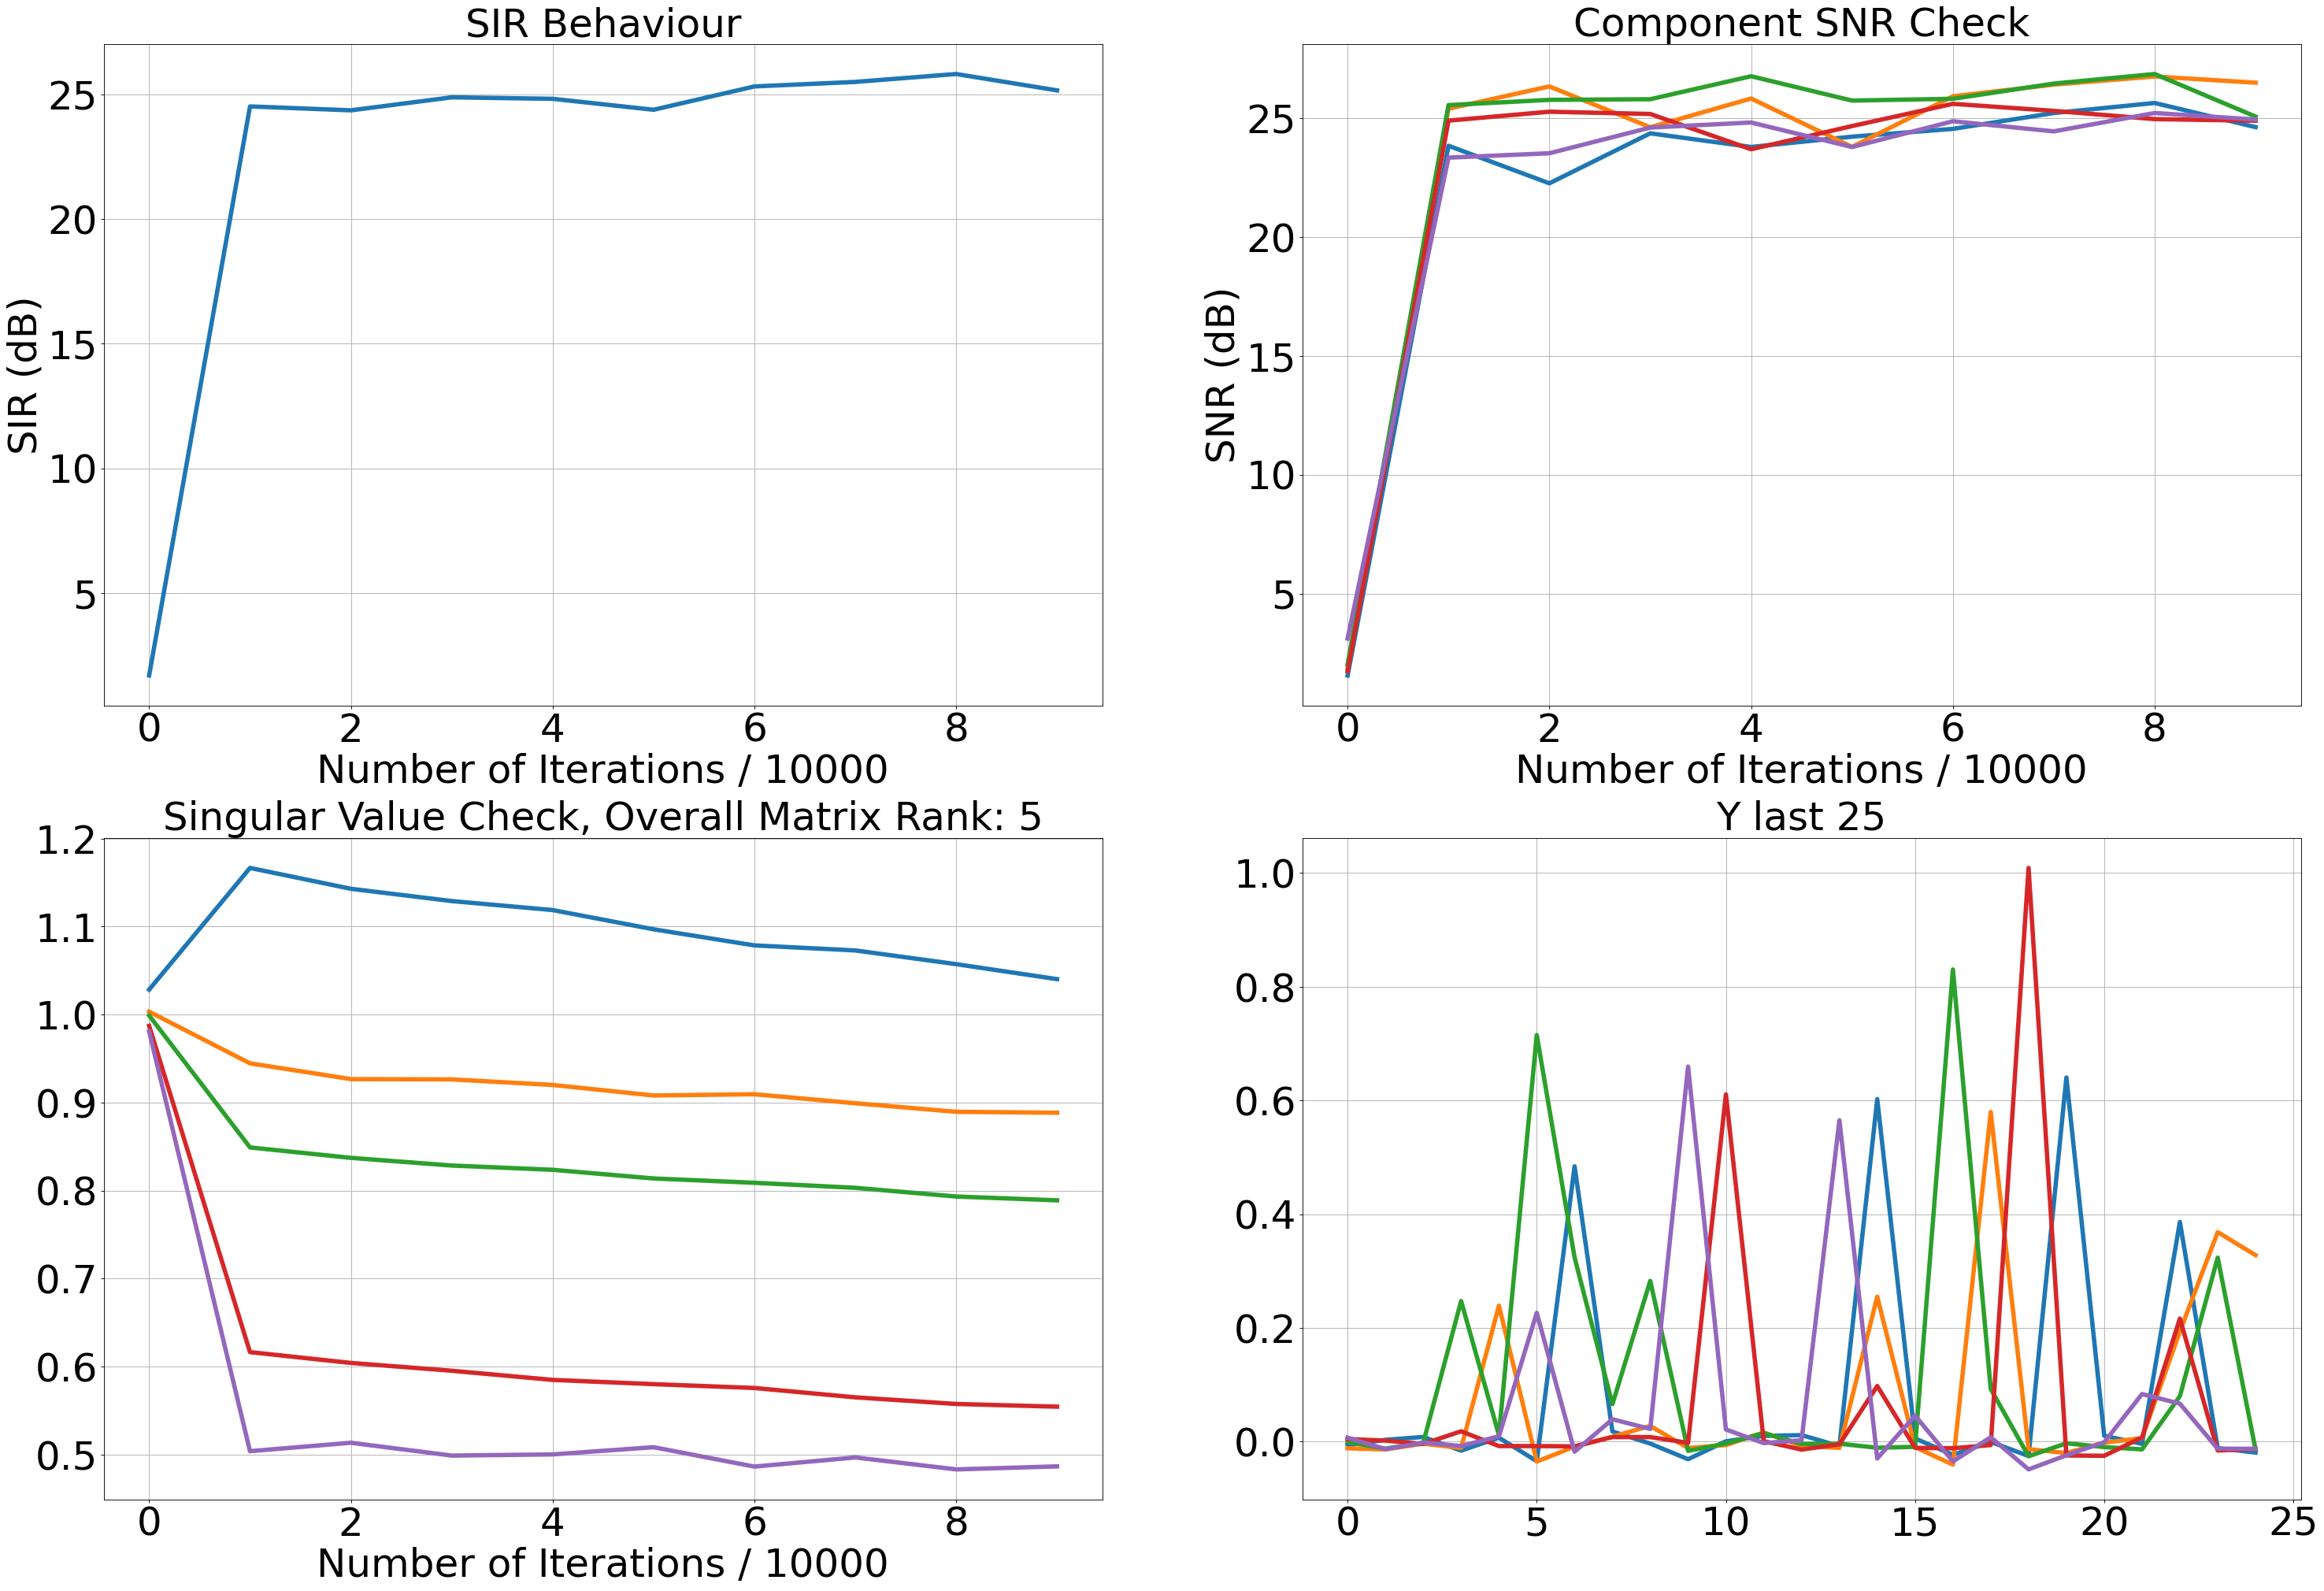

In [7]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "nnsparse",
                ### Optimization parameters
                "lambda_lateral" : 0.99,
                "gamma_predictive" : 100,
                ### Learning rates 
                "lr_W" : 3 * 1e-2,
                "neural_lr_start" : 0.1,
                "neural_lr_stop" : 1e-4,
                "stlambda_lr" : 0.1,
                "neural_dynamics_iterations" : 250,
                "neural_OUTPUT_COMP_TOL" : 1e-7,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_log_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 10000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrBSS(**hyperparam_dict)
model.fit(X)

In [8]:
display_matrix(model.C_y)

<IPython.core.display.Math object>

In [9]:
display_matrix(model.mu_y.reshape(1, -1))

<IPython.core.display.Math object>

In [10]:
display_matrix(model.W)

<IPython.core.display.Math object>

In [11]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(Y_, S)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 25.020130457420564
Component Signal-to-Noise-Ratio (SNR) Values : [24.24445839 25.34415029 25.55574891 25.4921296  24.68697593]



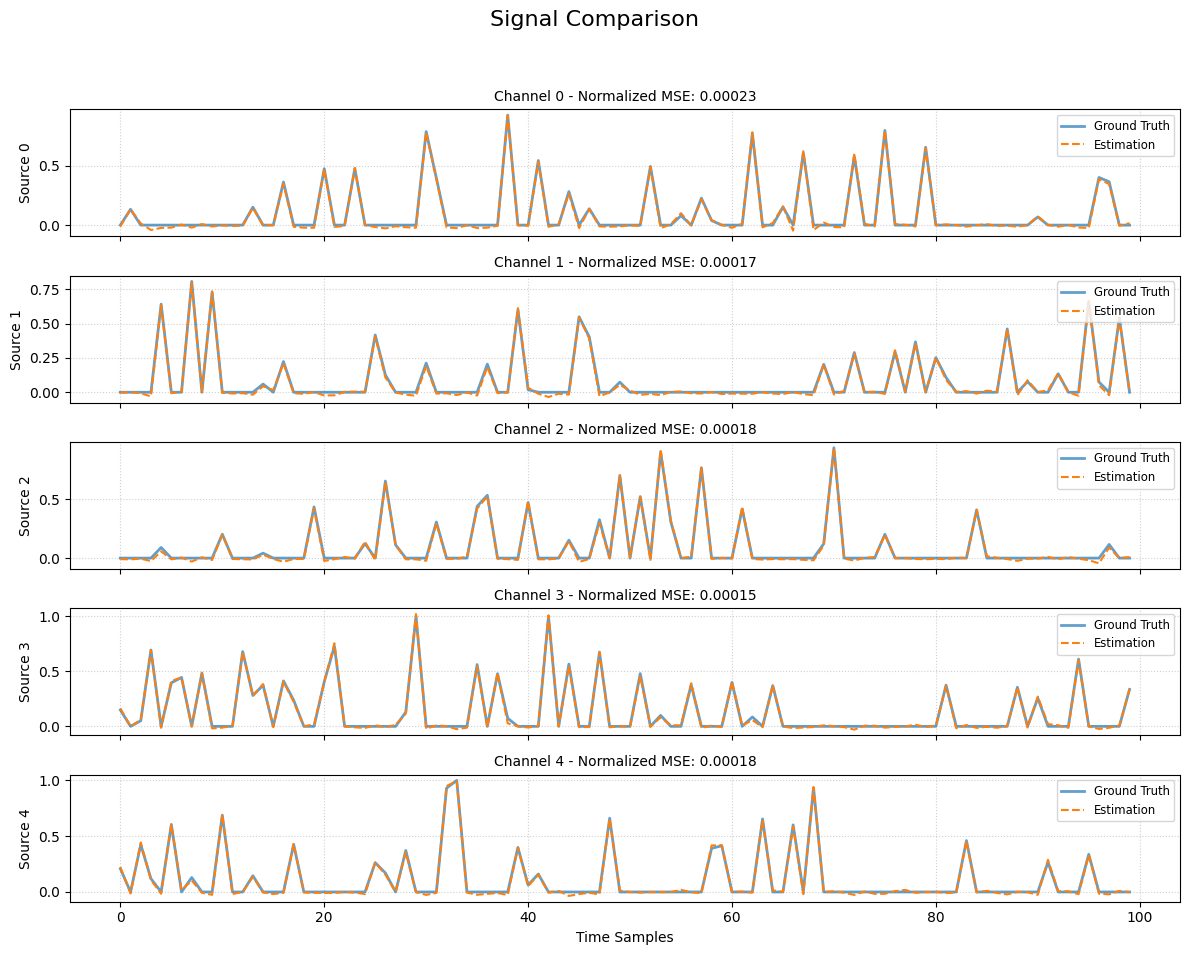

In [12]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])